## Kelly–Yudovina Markov limit order book

In [1]:
import numpy as np
import heapq
import matplotlib.pyplot as plt

In [2]:


class MarkovLOB:
    """
    Kelly–Yudovina Markov limit order book (unit orders, no cancellations)
    """

    def __init__(self, price_sampler_bid, price_sampler_ask, p_bid=0.5, seed=None):
        self.rng = np.random.default_rng(seed)

        # Min-heap for asks
        self.asks = []
        # Max-heap for bids (store negative prices)
        self.bids = []

        self.price_sampler_bid = price_sampler_bid
        self.price_sampler_ask = price_sampler_ask
        self.p_bid = p_bid

        self.time = 0.0

        # Tracking
        self.highest_bid_history = []
        self.lowest_ask_history = []
        self.time_history = []

    def step(self):
        """One Markov jump (one order arrival)"""

        # Interarrival time (unit-rate Poisson)
        dt = self.rng.exponential(1.0)
        self.time += dt

        is_bid = self.rng.random() < self.p_bid

        if is_bid:
            price = self.price_sampler_bid(self.rng)
            self._process_bid(price)
        else:
            price = self.price_sampler_ask(self.rng)
            self._process_ask(price)

        self._record_state()

    def _process_bid(self, price):
        # Match if possible
        if self.asks and price >= self.asks[0]:
            heapq.heappop(self.asks)  # remove lowest ask
        else:
            heapq.heappush(self.bids, -price)

    def _process_ask(self, price):
        # Match if possible
        if self.bids and price <= -self.bids[0]:
            heapq.heappop(self.bids)  # remove highest bid
        else:
            heapq.heappush(self.asks, price)

    def _record_state(self):
        hb = -self.bids[0] if self.bids else np.nan
        la = self.asks[0] if self.asks else np.nan

        self.highest_bid_history.append(hb)
        self.lowest_ask_history.append(la)
        self.time_history.append(self.time)

    def run(self, n_steps):
        for _ in range(n_steps):
            self.step()

In [3]:
def uniform_price(rng):
    return rng.uniform(0.0, 1.0)

lob = MarkovLOB(
    price_sampler_bid=uniform_price,
    price_sampler_ask=uniform_price,
    seed=42
)

lob.run(200_000)

In [4]:
burn_in = 50_000

hb = np.array(lob.highest_bid_history[burn_in:])
la = np.array(lob.lowest_ask_history[burn_in:])

hb = hb[~np.isnan(hb)]
la = la[~np.isnan(la)]

# Histograms
bins = np.linspace(0, 1, 200)

hb_density, _ = np.histogram(hb, bins=bins, density=True)
la_density, _ = np.histogram(la, bins=bins, density=True)

bin_centers = 0.5 * (bins[1:] + bins[:-1])

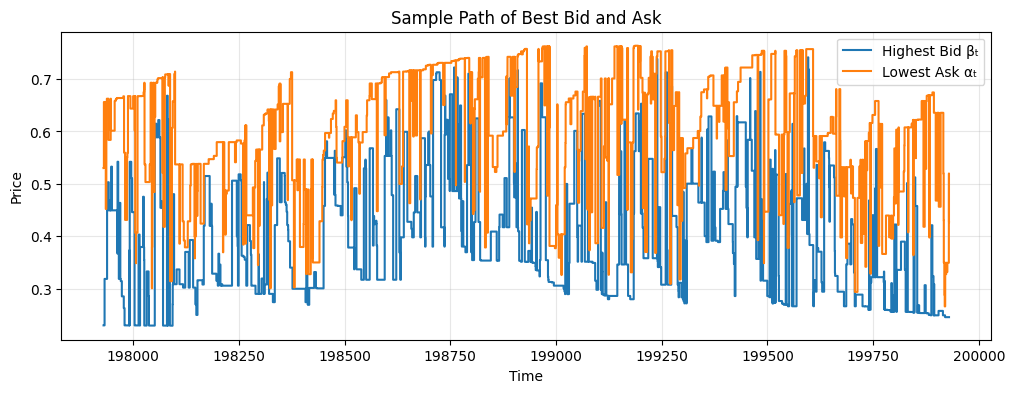

In [5]:
t = np.array(lob.time_history)
hb = np.array(lob.highest_bid_history)
la = np.array(lob.lowest_ask_history)

# Plot only a window to avoid clutter
idx = (t > t[-1] - 2000)

plt.figure(figsize=(12,4))
plt.step(t[idx], hb[idx], where="post", label="Highest Bid βₜ")
plt.step(t[idx], la[idx], where="post", label="Lowest Ask αₜ")

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Sample Path of Best Bid and Ask")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

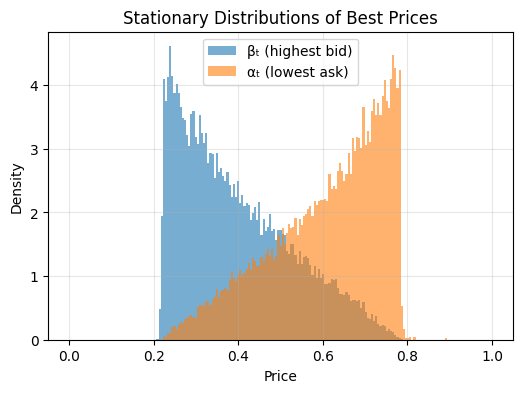

In [6]:
bins = np.linspace(0, 1, 200)

hb_clean = hb[~np.isnan(hb)]
la_clean = la[~np.isnan(la)]

plt.figure(figsize=(6,4))
plt.hist(hb_clean, bins=bins, density=True, alpha=0.6, label="βₜ (highest bid)")
plt.hist(la_clean, bins=bins, density=True, alpha=0.6, label="αₜ (lowest ask)")

plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Stationary Distributions of Best Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# empirical CDF tails
hb_sorted = np.sort(hb_clean)
la_sorted = np.sort(la_clean)

kappa_b_hat = np.percentile(hb_sorted, 1)      # ~ κ
kappa_a_hat = np.percentile(la_sorted, 99)     # ~ 1-κ

print("Estimated κ_b:", kappa_b_hat)
print("Estimated κ_a:", kappa_a_hat)

Estimated κ_b: 0.22059858297561644
Estimated κ_a: 0.7824799151076199


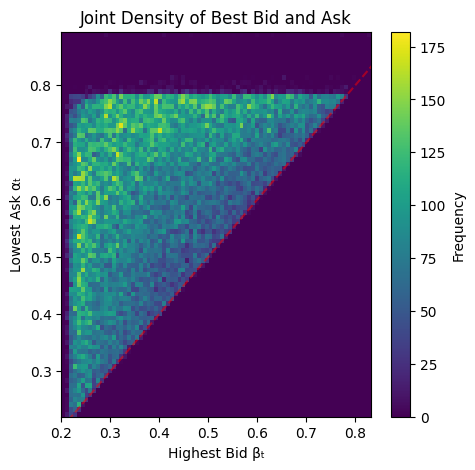

In [8]:
hb = np.array(lob.highest_bid_history)
la = np.array(lob.lowest_ask_history)

# joint mask
mask = (~np.isnan(hb)) & (~np.isnan(la))

hb_joint = hb[mask]
la_joint = la[mask]

plt.figure(figsize=(5,5))
plt.hist2d(hb_joint, la_joint, bins=80, cmap="viridis")
plt.xlabel("Highest Bid βₜ")
plt.ylabel("Lowest Ask αₜ")
plt.title("Joint Density of Best Bid and Ask")
plt.colorbar(label="Frequency")
plt.plot([0,1], [0,1], "r--", alpha=0.5)
plt.show()

# Binned CTMC

In [ ]:
class BinnedLOB_CTMC:
    """
    Kelly–Yudovina binned CTMC limit order book
    """

    def __init__(self, N=50, seed=None):
        self.N = N
        self.rng = np.random.default_rng(seed)

        # queues
        self.Qb = np.zeros(N, dtype=int)
        self.Qa = np.zeros(N, dtype=int)

        self.time = 0.0

        # history
        self.time_hist = []
        self.beta_hist = []
        self.alpha_hist = []

        # uniform arrival probabilities
        self.pb = np.ones(N) / N
        self.pa = np.ones(N) / N

    def _highest_bid_bin(self):
        idx = np.where(self.Qb > 0)[0]
        return idx[-1] if len(idx) > 0 else None

    def _lowest_ask_bin(self):
        idx = np.where(self.Qa > 0)[0]
        return idx[0] if len(idx) > 0 else None

    def step(self):
        # CTMC jump time
        dt = self.rng.exponential(1.0)
        self.time += dt

        # bid or ask
        is_bid = self.rng.random() < 0.5

        # arrival bin
        k = self.rng.integers(0, self.N)

        if is_bid:
            self._process_bid(k)
        else:
            self._process_ask(k)

        self._record()

    def _process_bid(self, k):
        # find lowest ask ≤ k
        asks = np.where(self.Qa[:k+1] > 0)[0]
        if len(asks) > 0:
            self.Qa[asks[0]] -= 1
        else:
            self.Qb[k] += 1

    def _process_ask(self, k):
        # find highest bid ≥ k
        bids = np.where(self.Qb[k:] > 0)[0]
        if len(bids) > 0:
            self.Qb[k + bids[-1]] -= 1
        else:
            self.Qa[k] += 1

    def _record(self):
        hb = self._highest_bid_bin()
        la = self._lowest_ask_bin()

        self.time_hist.append(self.time)
        self.beta_hist.append(hb)
        self.alpha_hist.append(la)

    def run(self, n_steps):
        for _ in range(n_steps):
            self.step()

In [10]:
lob = BinnedLOB_CTMC(N=60, seed=42)
lob.run(300_000)

In [15]:
N = lob.N
bin_centers = (np.arange(N) + 0.5) / N

beta = np.array([b if b is not None else -1 for b in lob.beta_hist])
alpha = np.array([a if a is not None else -1 for a in lob.alpha_hist])

beta_price = np.where(beta >= 0, bin_centers[beta], np.nan)
alpha_price = np.where(alpha >= 0, bin_centers[alpha], np.nan)

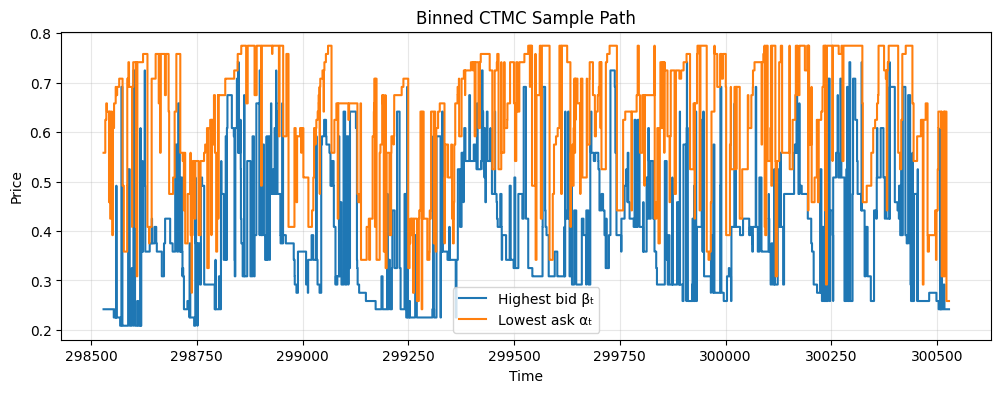

In [ ]:
t = np.array(lob.time_hist)

idx = t > t[-1] - 2000

plt.figure(figsize=(12,4))
plt.step(t[idx], beta_price[idx], where="post", label="Highest bid βₜ")
plt.step(t[idx], alpha_price[idx], where="post", label="Lowest ask αₜ")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Binned CTMC Sample Path")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

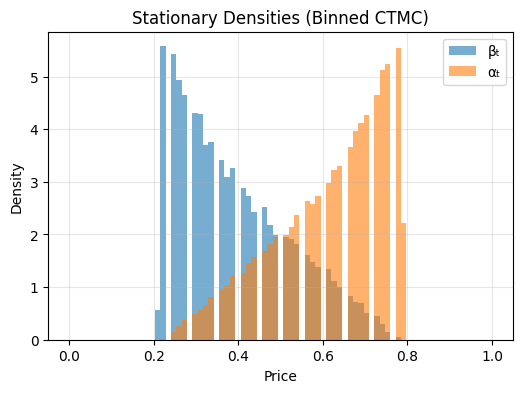

In [17]:
burn = 50_000

beta_clean = beta_price[burn:]
alpha_clean = alpha_price[burn:]

beta_clean = beta_clean[~np.isnan(beta_clean)]
alpha_clean = alpha_clean[~np.isnan(alpha_clean)]

bins = np.linspace(0,1,80)

plt.figure(figsize=(6,4))
plt.hist(beta_clean, bins=bins, density=True, alpha=0.6, label="βₜ")
plt.hist(alpha_clean, bins=bins, density=True, alpha=0.6, label="αₜ")
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Stationary Densities (Binned CTMC)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

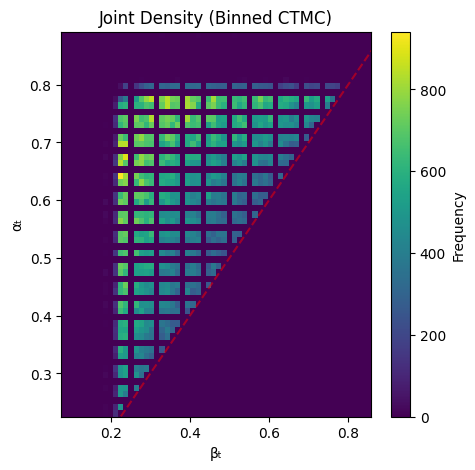

In [18]:
mask = (~np.isnan(beta_price)) & (~np.isnan(alpha_price))

plt.figure(figsize=(5,5))
plt.hist2d(beta_price[mask], alpha_price[mask],
           bins=60, cmap="viridis")
plt.plot([0,1],[0,1],'r--',alpha=0.5)
plt.xlabel("βₜ")
plt.ylabel("αₜ")
plt.title("Joint Density (Binned CTMC)")
plt.colorbar(label="Frequency")
plt.show()

A1. Helper: run CTMC and estimate κ

In [19]:
import numpy as np

def estimate_kappa_b(N, n_steps=250_000, burn=50_000, seed=0):
    lob = BinnedLOB_CTMC(N=N, seed=seed)
    lob.run(n_steps)

    bin_centers = (np.arange(N) + 0.5) / N

    beta = np.array([b if b is not None else -1 for b in lob.beta_hist])
    beta_price = np.where(beta >= 0, bin_centers[beta], np.nan)

    beta_clean = beta_price[burn:]
    beta_clean = beta_clean[~np.isnan(beta_clean)]

    # left edge of stationary support
    return np.percentile(beta_clean, 1)

A2. Run for increasing N

In [20]:
Ns = [10, 20, 30, 50, 80, 120, 200]
kappa_est = []

for N in Ns:
    kappa_est.append(estimate_kappa_b(N))

kappa_est = np.array(kappa_est)

A3. Plot convergence

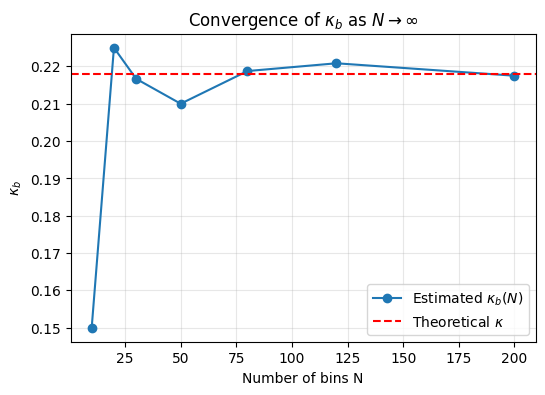

In [21]:
kappa_theory = 0.218  # theoretical value

plt.figure(figsize=(6,4))
plt.plot(Ns, kappa_est, "o-", label=r"Estimated $\kappa_b(N)$")
plt.axhline(kappa_theory, color="red", linestyle="--",
            label=r"Theoretical $\kappa$")
plt.xlabel("Number of bins N")
plt.ylabel(r"$\kappa_b$")
plt.title(r"Convergence of $\kappa_b$ as $N \to \infty$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

PART B — Overlay theoretical 
𝜋
𝑏
(
𝑥
)
π
b
	​

(x)

B1. Theoretical density function

In [22]:
def pi_b_theoretical(x, kappa=0.218):
    out = np.zeros_like(x)
    mask = (x > kappa) & (x < 1 - kappa)
    out[mask] = (1 - kappa) * (
        1/x[mask] + np.log((1 - x[mask]) / x[mask])
    )
    return out

B2. Empirical density from binned CTMC

In [23]:
N = 200
lob = BinnedLOB_CTMC(N=N, seed=1)
lob.run(400_000)

bin_centers = (np.arange(N) + 0.5) / N

beta = np.array([b if b is not None else -1 for b in lob.beta_hist])
beta_price = np.where(beta >= 0, bin_centers[beta], np.nan)

burn = 80_000
beta_clean = beta_price[burn:]
beta_clean = beta_clean[~np.isnan(beta_clean)]

B3. Overlay plot

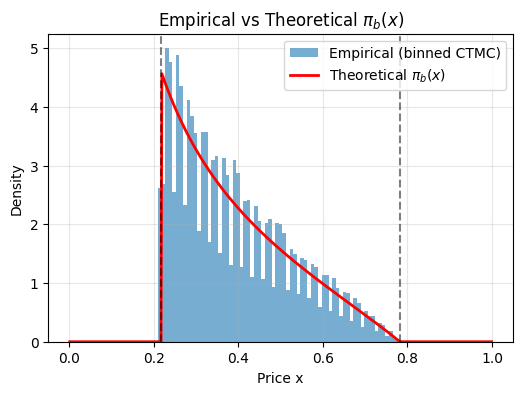

In [24]:
bins = np.linspace(0, 1, 120)

plt.figure(figsize=(6,4))
plt.hist(beta_clean, bins=bins, density=True,
         alpha=0.6, label="Empirical (binned CTMC)")

x = np.linspace(0.001, 0.999, 500)
plt.plot(x, pi_b_theoretical(x),
         "r", lw=2, label=r"Theoretical $\pi_b(x)$")

plt.axvline(0.218, color="k", linestyle="--", alpha=0.5)
plt.axvline(1-0.218, color="k", linestyle="--", alpha=0.5)

plt.xlabel("Price x")
plt.ylabel("Density")
plt.title(r"Empirical vs Theoretical $\pi_b(x)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

C1. Helper: estimate 
𝜅
𝑎
(
𝑁
)
κ
a
	​

(N)

In [25]:
def estimate_kappa_a(N, n_steps=250_000, burn=50_000, seed=0):
    lob = BinnedLOB_CTMC(N=N, seed=seed)
    lob.run(n_steps)

    bin_centers = (np.arange(N) + 0.5) / N

    alpha = np.array([a if a is not None else -1 for a in lob.alpha_hist])
    alpha_price = np.where(alpha >= 0, bin_centers[alpha], np.nan)

    alpha_clean = alpha_price[burn:]
    alpha_clean = alpha_clean[~np.isnan(alpha_clean)]

    # right edge of stationary support
    return np.percentile(alpha_clean, 99)

C2. Run for increasing N

In [26]:
Ns = [10, 20, 30, 50, 80, 120, 200]
kappa_a_est = []

for N in Ns:
    kappa_a_est.append(estimate_kappa_a(N))

kappa_a_est = np.array(kappa_a_est)

C3. Plot convergence

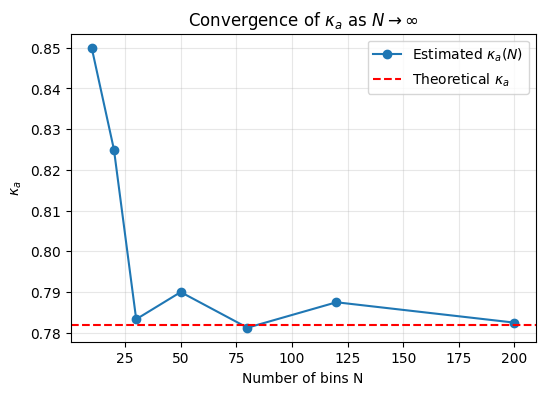

In [27]:
kappa_theory = 1 - 0.218  # ≈ 0.782

plt.figure(figsize=(6,4))
plt.plot(Ns, kappa_a_est, "o-", label=r"Estimated $\kappa_a(N)$")
plt.axhline(kappa_theory, color="red", linestyle="--",
            label=r"Theoretical $\kappa_a$")
plt.xlabel("Number of bins N")
plt.ylabel(r"$\kappa_a$")
plt.title(r"Convergence of $\kappa_a$ as $N \to \infty$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

D1. Theoretical 
𝜋
𝑎
π
a
	​

 (uniform arrivals)

In [28]:
def pi_a_theoretical(x, kappa=0.218):
    return pi_b_theoretical(1 - x, kappa)

D2. Empirical 
𝜋
𝑎
π
a
	​

 from binned CTMC

In [29]:
N = 200
lob = BinnedLOB_CTMC(N=N, seed=2)
lob.run(400_000)

bin_centers = (np.arange(N) + 0.5) / N

alpha = np.array([a if a is not None else -1 for a in lob.alpha_hist])
alpha_price = np.where(alpha >= 0, bin_centers[alpha], np.nan)

burn = 80_000
alpha_clean = alpha_price[burn:]
alpha_clean = alpha_clean[~np.isnan(alpha_clean)]

D3. Overlay plot: empirical vs theoretical 
𝜋
𝑎
π
a
	​


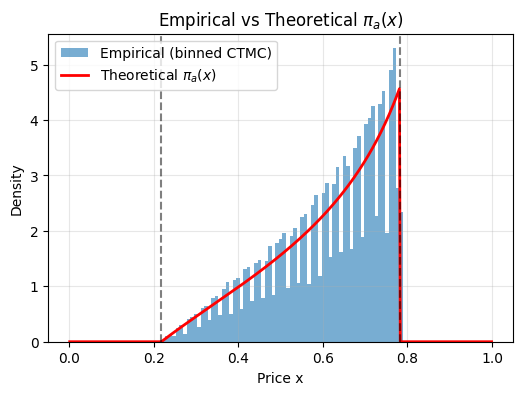

In [30]:
bins = np.linspace(0, 1, 120)

plt.figure(figsize=(6,4))
plt.hist(alpha_clean, bins=bins, density=True,
         alpha=0.6, label="Empirical (binned CTMC)")

x = np.linspace(0.001, 0.999, 500)
plt.plot(x, pi_a_theoretical(x),
         "r", lw=2, label=r"Theoretical $\pi_a(x)$")

plt.axvline(0.218, color="k", linestyle="--", alpha=0.5)
plt.axvline(1-0.218, color="k", linestyle="--", alpha=0.5)

plt.xlabel("Price x")
plt.ylabel("Density")
plt.title(r"Empirical vs Theoretical $\pi_a(x)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()